## Первичное тестирование SVD в numpy

In [1]:
import numpy as np

In [2]:
a = np.random.rand(8).reshape(2, 4)

In [3]:
a

array([[0.83967061, 0.30101891, 0.67494374, 0.98723142],
       [0.74089539, 0.04157473, 0.80176675, 0.28992439]])

In [4]:
np.linalg.svd(a)

SVDResult(U=array([[ 0.8088563 , -0.58800637],
       [ 0.58800637,  0.8088563 ]]), S=array([1.81346206, 0.46338955]), Vh=array([[ 0.61474904,  0.1477435 ,  0.56101336,  0.53434023],
       [ 0.22776998, -0.30940071,  0.5430482 , -0.74665299],
       [-0.67198989,  0.45229184,  0.5854461 ,  0.03338486],
       [-0.34443292, -0.82333174,  0.21820983,  0.39481044]]))

In [5]:
a.size

8

## Практика SVD

### Загрузим датасет MNIST, чтобы найти сингулярное разложение одной из картинок

In [6]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

# Загружаем MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

In [7]:
X = mnist.data

In [8]:
X.shape

(70000, 784)

In [9]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

### Возьмем изображение с цифрой 5 и найдем его сингулярное разложение

In [10]:
image = X[0]

In [11]:
image.shape

(784,)

In [12]:
image = image.reshape(28, 28)

In [13]:
U, S, Vt = np.linalg.svd(image)

In [14]:
S

array([1.83037586e+03, 1.08654815e+03, 7.43679137e+02, 5.54034051e+02,
       4.93834223e+02, 3.66461299e+02, 2.75523825e+02, 2.15874591e+02,
       1.35092524e+02, 1.08927271e+02, 7.89483974e+01, 6.74274439e+01,
       6.51581799e+01, 3.71184015e+01, 3.29718168e+01, 2.21705957e+01,
       1.72080970e+01, 7.34561612e+00, 1.42215604e+00, 1.73302153e-02,
       1.22076704e-13, 1.22076704e-13, 1.22076704e-13, 1.22076704e-13,
       1.22076704e-13, 1.22076704e-13, 1.22076704e-13, 1.22076704e-13])

### Визуализация сингулярных чисел

Отобразим полученные сингулярные числа по убыванию, чтобы выяснить наиболее значимые.

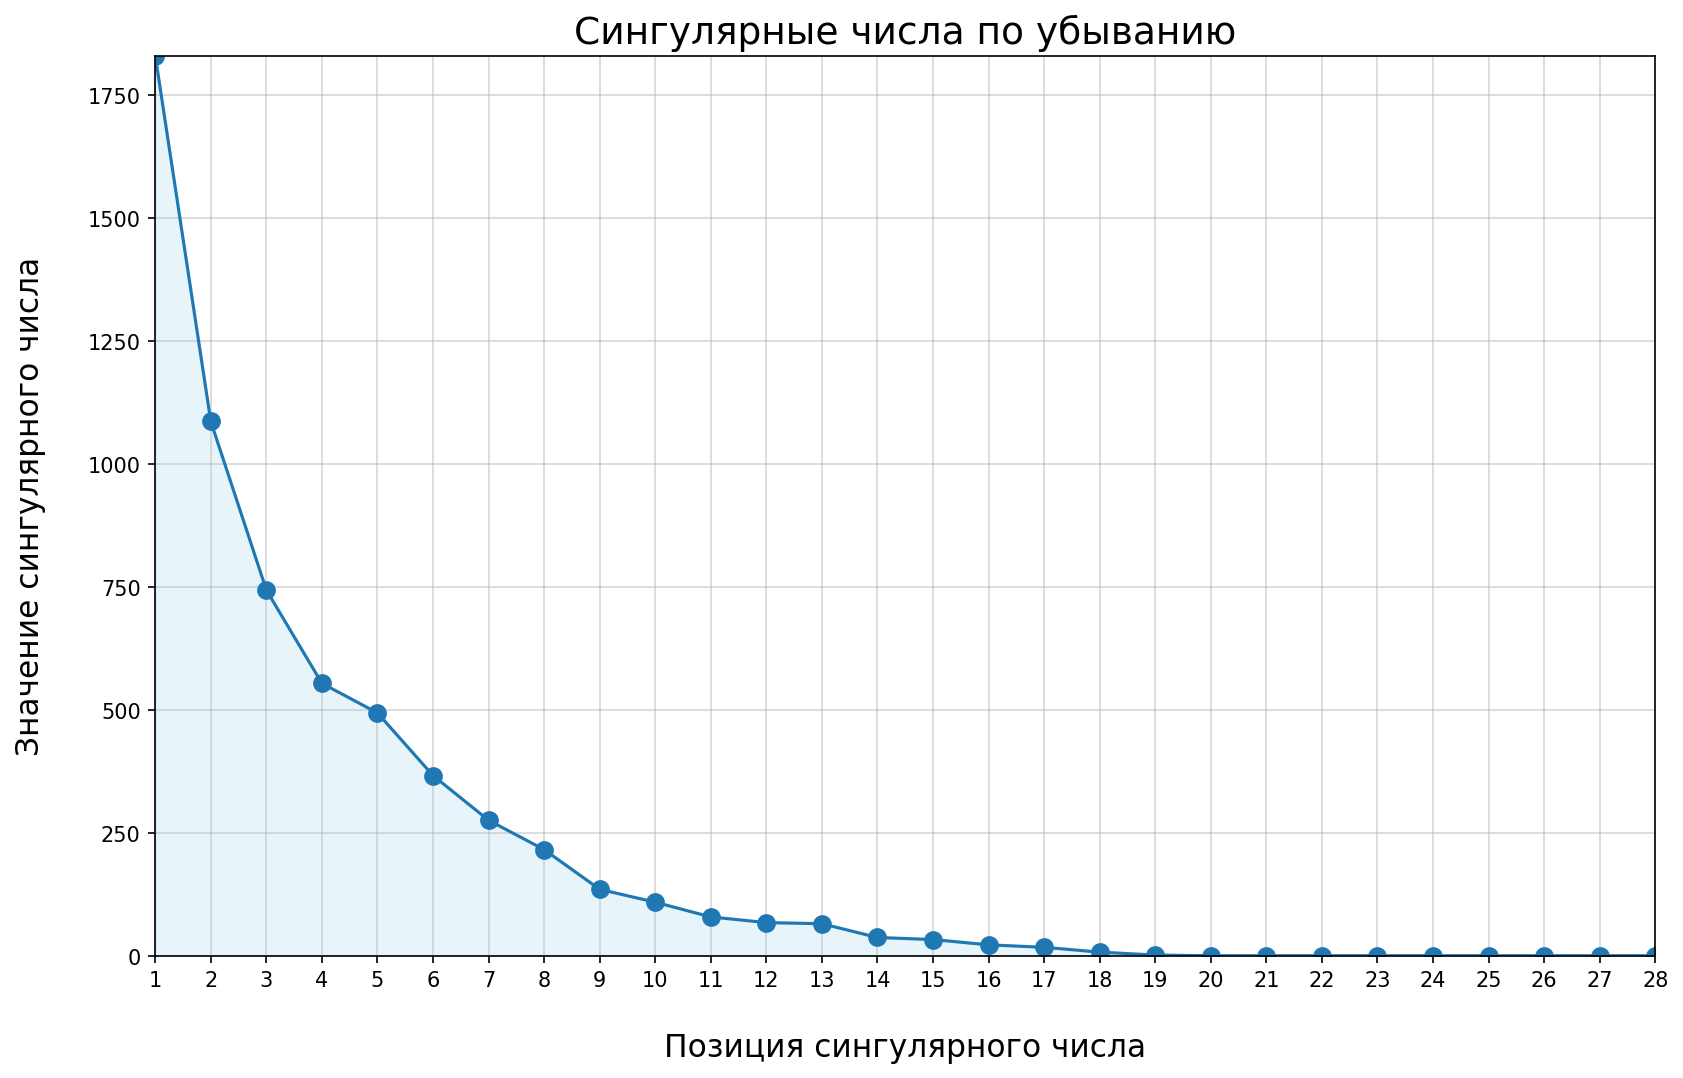

In [24]:
fig = plt.figure(dpi=150, figsize=(10, 6))
ax = fig.add_axes([0, 0, 1,1])

ax.plot(range(1, len(S)+1), S, marker='o', ms=8)
ax.set_xticks(range(1,29))
ax.fill_between(range(1, len(S)+1), S, 0, color='skyblue', alpha=0.2)
ax.set_title('Сингулярные числа по убыванию', fontsize=18)
ax.set_ylabel('Значение сингулярного числа', fontsize=15, labelpad=20)
ax.set_xlabel('Позиция сингулярного числа', fontsize=15, labelpad=20)
ax.margins(x=0,y=0)
ax.grid(alpha=0.5)

plt.show()

In [25]:
plt.savefig("figures/singular_values_desc.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

Можно увидеть, что сингулярные числа после тринадцатого перестают сильно скалировать оси.

### Напишем функцию понижения размерности алгоритмом PCA

In [17]:
def PCA(U, S, Vt, k:int):
    ''' Восстановление матрицы с использованием только k компонент '''
    k = int(k)
    return U[:,:k] @ np.diag(S[:k]) @ Vt[:k,:]

### Пример применения функции

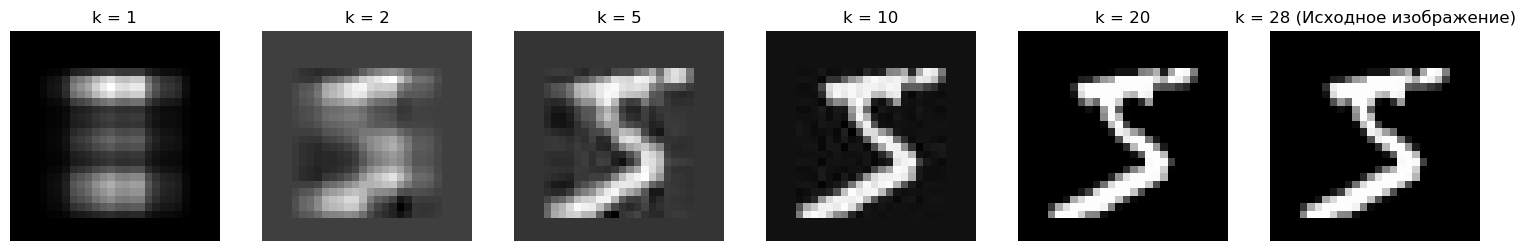

In [18]:
k_values = [1, 2, 5, 10, 20, 28] # Количества сингулярных чисел
plt.figure(figsize=(15, 5))

for i, k in enumerate(k_values):
    plt.subplot(1, len(k_values), i + 1)
    reconstructed = PCA(U, S, Vt, k)
    plt.imshow(reconstructed, cmap='gray')
    if k == len(S):
        plt.title(f"k = {k} (Исходное изображение)")
    else:
        plt.title(f"k = {k}")
    plt.tight_layout()
    plt.axis('off')

In [19]:
plt.savefig("figures/image_compasrion.png")

<Figure size 640x480 with 0 Axes>

### Вывод:

Оставив 20 сингулярных чисел из 28, мы получаем картинку без потерь, на 10 сингулярных числах видны небольшие потери в качестве, а на более низких значениях изображение становится все менее читаемым